# GeM Bid Compliance Classification
Predict whether a tender bid **PASS**es or **FAIL**s compliance based on financial, technical, legal, and documentation attributes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42

## 1. Load Data

In [2]:
df = pd.read_csv('gem_bid_compliance_dataset_5000.csv')
print("Shape:", df.shape)
df.head()

Shape: (5000, 22)


,tender_id,turnover_crore,required_turnover_crore,experience_years,required_experience_years,gst_valid,pan_valid,udyam_valid,oem_authorization,technical_score,...,financial_compliance,eligibility_compliance,mandatory_documents_complete,missing_documents,local_content_percent,required_local_content_percent,certificate_validity,blacklist_clear,compliance_score,result
0,T00001,3.82,5,1.5,2,1,1,1,1,91.5,...,0,0,1,2,43.4,30,1,1,91.3,PASS
1,T00002,6.82,20,1.7,1,1,1,1,1,72.7,...,0,1,1,2,47.0,50,1,1,91.5,PASS
2,T00003,8.31,10,10.8,10,1,1,1,1,69.0,...,0,1,1,0,54.5,40,1,1,96.3,PASS
3,T00004,10.56,7,3.4,3,1,1,0,1,68.4,...,1,1,1,1,26.4,50,1,1,78.7,FAIL
4,T00005,2.55,2,4.2,3,1,1,0,0,78.3,...,1,1,1,1,69.6,50,1,1,76.3,PASS


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   tender_id                       5000 non-null   str    
 1   turnover_crore                  5000 non-null   float64
 2   required_turnover_crore         5000 non-null   int64  
 3   experience_years                5000 non-null   float64
 4   required_experience_years       5000 non-null   int64  
 5   gst_valid                       5000 non-null   int64  
 6   pan_valid                       5000 non-null   int64  
 7   udyam_valid                     5000 non-null   int64  
 8   oem_authorization               5000 non-null   int64  
 9   technical_score                 5000 non-null   float64
 10  minimum_technical_score         5000 non-null   int64  
 11  technical_compliance            5000 non-null   int64  
 12  financial_compliance            5000 non-null

In [4]:
df.describe()

,turnover_crore,required_turnover_crore,experience_years,required_experience_years,gst_valid,pan_valid,udyam_valid,oem_authorization,technical_score,minimum_technical_score,technical_compliance,financial_compliance,eligibility_compliance,mandatory_documents_complete,missing_documents,local_content_percent,required_local_content_percent,certificate_validity,blacklist_clear,compliance_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,7.871428,7.209000,4.525360,4.298600,0.930600,0.949800,0.72260,0.774800,77.400540,67.751000,0.573600,0.493000,0.49940,0.823000,1.298200,54.754400,36.528000,0.883000,0.957000,81.24176
std,7.648959,5.518823,3.400922,2.612126,0.254159,0.218379,0.44776,0.417756,14.236427,5.093347,0.494603,0.500001,0.50005,0.381707,1.151843,21.600193,11.132385,0.321452,0.202877,14.62565
min,0.270000,1.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,30.000000,60.000000,0.000000,0.000000,0.00000,0.000000,0.000000,5.000000,20.000000,0.000000,0.000000,23.90000
25%,2.660000,3.000000,1.800000,2.000000,1.000000,1.000000,0.00000,1.000000,67.700000,65.000000,0.000000,0.000000,0.00000,1.000000,0.000000,40.000000,30.000000,1.000000,1.000000,71.40000
50%,5.385000,5.000000,4.100000,3.000000,1.000000,1.000000,1.00000,1.000000,77.900000,70.000000,1.000000,0.000000,0.00000,1.000000,1.000000,54.700000,40.000000,1.000000,1.000000,83.10000
75%,10.402500,10.000000,6.700000,5.000000,1.000000,1.000000,1.00000,1.000000,88.400000,70.000000,1.000000,1.000000,1.00000,1.000000,2.000000,69.700000,50.000000,1.000000,1.000000,93.80000
max,97.890000,20.000000,18.200000,10.000000,1.000000,1.000000,1.00000,1.000000,100.000000,75.000000,1.000000,1.000000,1.00000,1.000000,7.000000,100.000000,50.000000,1.000000,1.000000,100.00000


### Check for missing values and duplicates

In [5]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
 tender_id                         0
turnover_crore                    0
required_turnover_crore           0
experience_years                  0
required_experience_years         0
gst_valid                         0
pan_valid                         0
udyam_valid                       0
oem_authorization                 0
technical_score                   0
minimum_technical_score           0
technical_compliance              0
financial_compliance              0
eligibility_compliance            0
mandatory_documents_complete      0
missing_documents                 0
local_content_percent             0
required_local_content_percent    0
certificate_validity              0
blacklist_clear                   0
compliance_score                  0
result                            0
dtype: int64

Duplicate rows: 0


## 2. Target Distribution

result
FAIL    2993
PASS    2007
Name: count, dtype: int64
result
FAIL    59.86
PASS    40.14
Name: proportion, dtype: float64


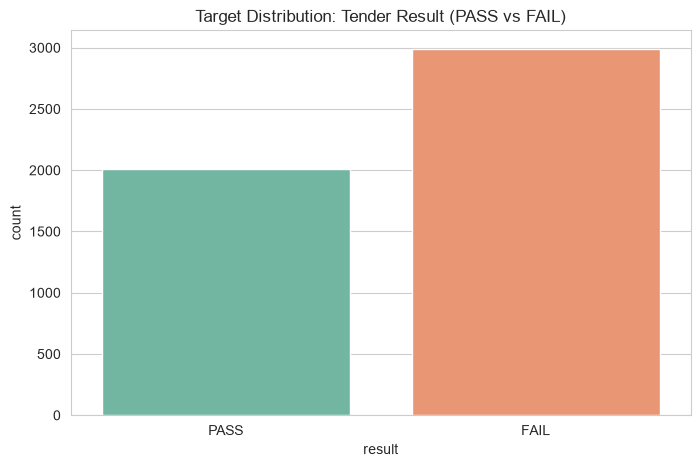

In [6]:
print(df['result'].value_counts())
print(df['result'].value_counts(normalize=True) * 100)

sns.countplot(data=df, x='result', palette='Set2')
plt.title('Target Distribution: Tender Result (PASS vs FAIL)')
plt.show()

## 3. Exploratory Data Analysis
Look at how key numeric features relate to the outcome.

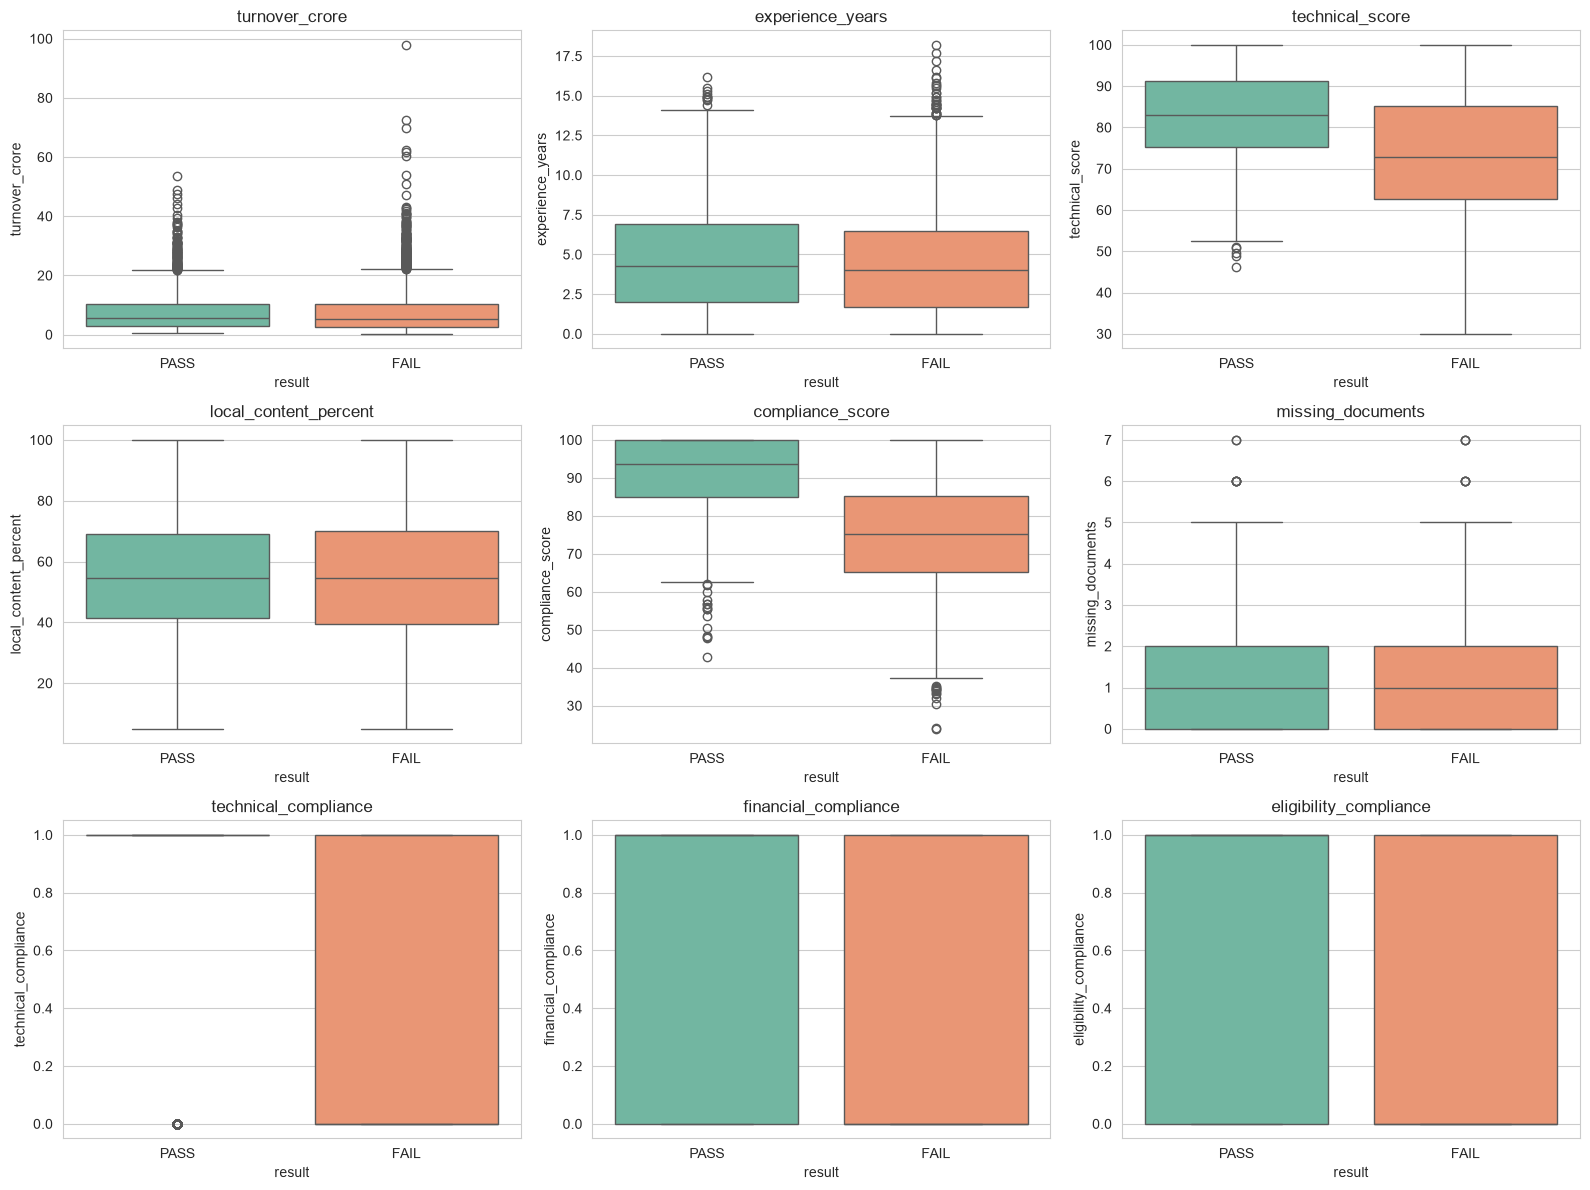

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
key_features = ['turnover_crore', 'experience_years', 'technical_score',
                 'local_content_percent', 'compliance_score', 'missing_documents',
                 'technical_compliance', 'financial_compliance', 'eligibility_compliance']

for ax, feat in zip(axes.flatten(), key_features):
    sns.boxplot(data=df, x='result', y=feat, ax=ax, palette='Set2')
    ax.set_title(feat)

plt.tight_layout()
plt.show()

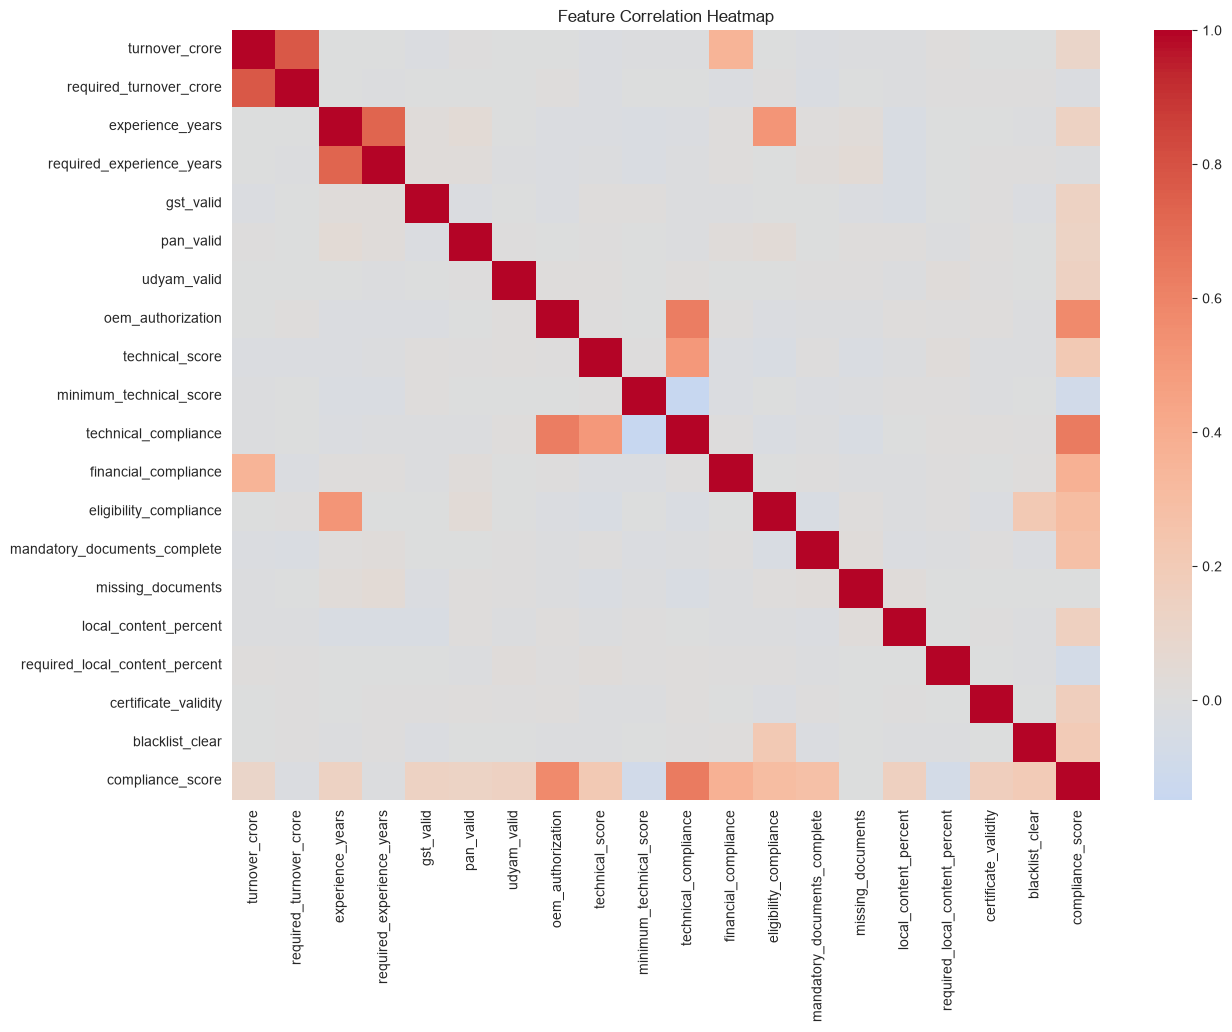

In [8]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

## 4. Feature Engineering
Create a few derived features that reflect compliance margins (how far above/below required thresholds each bid is), which are often more informative than raw values.

In [9]:
df_fe = df.copy()

df_fe['turnover_margin'] = df_fe['turnover_crore'] - df_fe['required_turnover_crore']
df_fe['experience_margin'] = df_fe['experience_years'] - df_fe['required_experience_years']
df_fe['technical_margin'] = df_fe['technical_score'] - df_fe['minimum_technical_score']
df_fe['local_content_margin'] = df_fe['local_content_percent'] - df_fe['required_local_content_percent']

df_fe.head()

,tender_id,turnover_crore,required_turnover_crore,experience_years,required_experience_years,gst_valid,pan_valid,udyam_valid,oem_authorization,technical_score,...,local_content_percent,required_local_content_percent,certificate_validity,blacklist_clear,compliance_score,result,turnover_margin,experience_margin,technical_margin,local_content_margin
0,T00001,3.82,5,1.5,2,1,1,1,1,91.5,...,43.4,30,1,1,91.3,PASS,-1.18,-0.5,21.5,13.4
1,T00002,6.82,20,1.7,1,1,1,1,1,72.7,...,47.0,50,1,1,91.5,PASS,-13.18,0.7,12.7,-3.0
2,T00003,8.31,10,10.8,10,1,1,1,1,69.0,...,54.5,40,1,1,96.3,PASS,-1.69,0.8,9.0,14.5
3,T00004,10.56,7,3.4,3,1,1,0,1,68.4,...,26.4,50,1,1,78.7,FAIL,3.56,0.4,-1.6,-23.6
4,T00005,2.55,2,4.2,3,1,1,0,0,78.3,...,69.6,50,1,1,76.3,PASS,0.55,1.2,18.3,19.6


## 5. Preprocessing

In [ ]:
X = df_fe.drop(columns=['tender_id', 'result'])
y = df_fe['result']

# Encode target: PASS -> 1, FAIL -> 0
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))

feature_names = X.columns.tolist()
print("\nFeatures used:", feature_names)

Classes: {'FAIL': np.int64(0), 'PASS': np.int64(1)}

Features used: ['turnover_crore', 'required_turnover_crore', 'experience_years', 'required_experience_years', 'gst_valid', 'pan_valid', 'udyam_valid', 'oem_authorization', 'technical_score', 'minimum_technical_score', 'technical_compliance', 'financial_compliance', 'eligibility_compliance', 'mandatory_documents_complete', 'missing_documents', 'local_content_percent', 'required_local_content_percent', 'certificate_validity', 'blacklist_clear', 'compliance_score', 'turnover_margin', 'experience_margin', 'technical_margin', 'local_content_margin']


## 6. Train / Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4000, 24)
Test shape: (1000, 24)


### Scale numeric features (for Logistic Regression)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Model Training
Train and compare three classifiers: Logistic Regression, Random Forest, and Gradient Boosting.

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'roc_auc': roc_auc_score(y_test, probs),
        'model': model,
        'preds': preds,
        'probs': probs
    }

results_df = pd.DataFrame({k: {m: v for m, v in val.items() if m in
    ['accuracy','precision','recall','f1','roc_auc']} for k, val in results.items()}).T
results_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.936,0.951743,0.885287,0.917313,0.955766
Random Forest,0.958,0.966234,0.927681,0.946565,0.958768
Gradient Boosting,0.959,0.963918,0.932668,0.948035,0.957891


## 8. Model Comparison

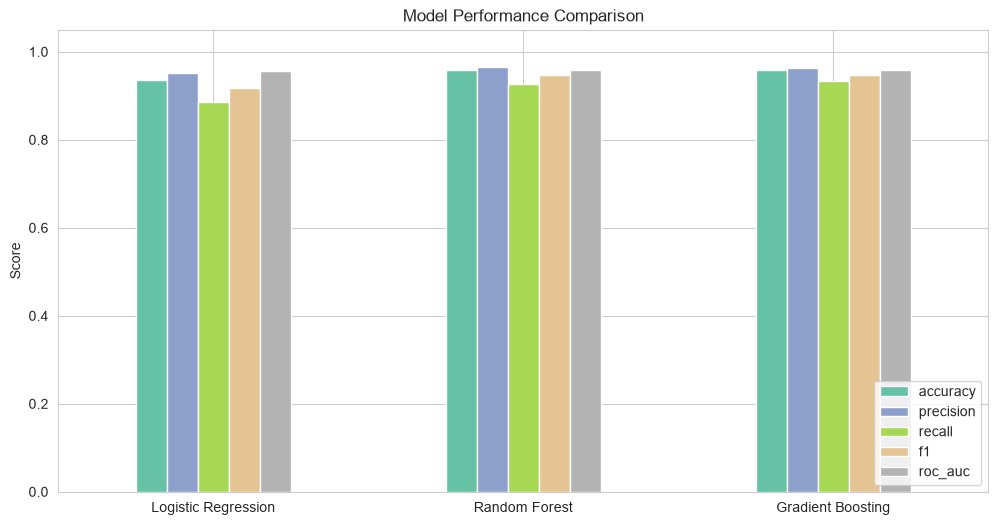

In [14]:
results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].plot(
    kind='bar', figsize=(12, 6), colormap='Set2'
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1.05)
plt.show()

## 9. Best Model — Detailed Evaluation

In [15]:
best_model_name = results_df['f1'].idxmax()
print(f"Best model based on F1-score: {best_model_name}")

best = results[best_model_name]
print("\nClassification Report:\n")
print(classification_report(y_test, best['preds'], target_names=le.classes_))

Best model based on F1-score: Gradient Boosting

Classification Report:

              precision    recall  f1-score   support

        FAIL       0.96      0.98      0.97       599
        PASS       0.96      0.93      0.95       401

    accuracy                           0.96      1000
   macro avg       0.96      0.95      0.96      1000
weighted avg       0.96      0.96      0.96      1000



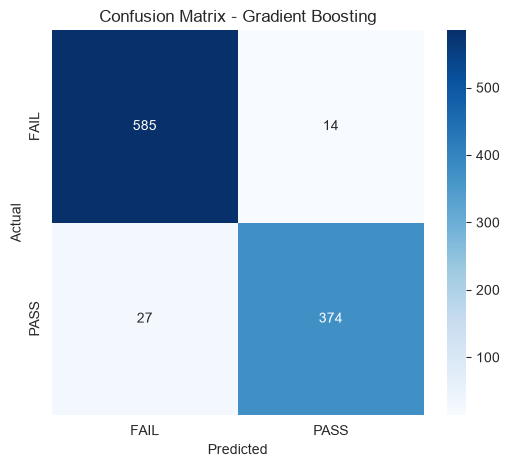

In [16]:
cm = confusion_matrix(y_test, best['preds'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

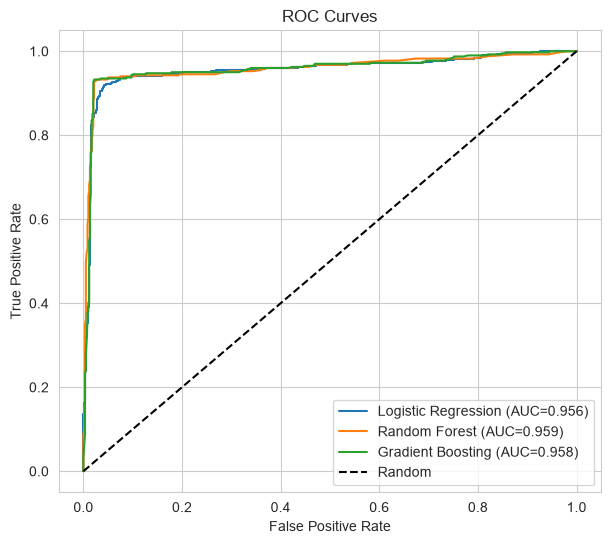

In [17]:
plt.figure(figsize=(7, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['probs'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

## 10. Feature Importance (Tree-based model)

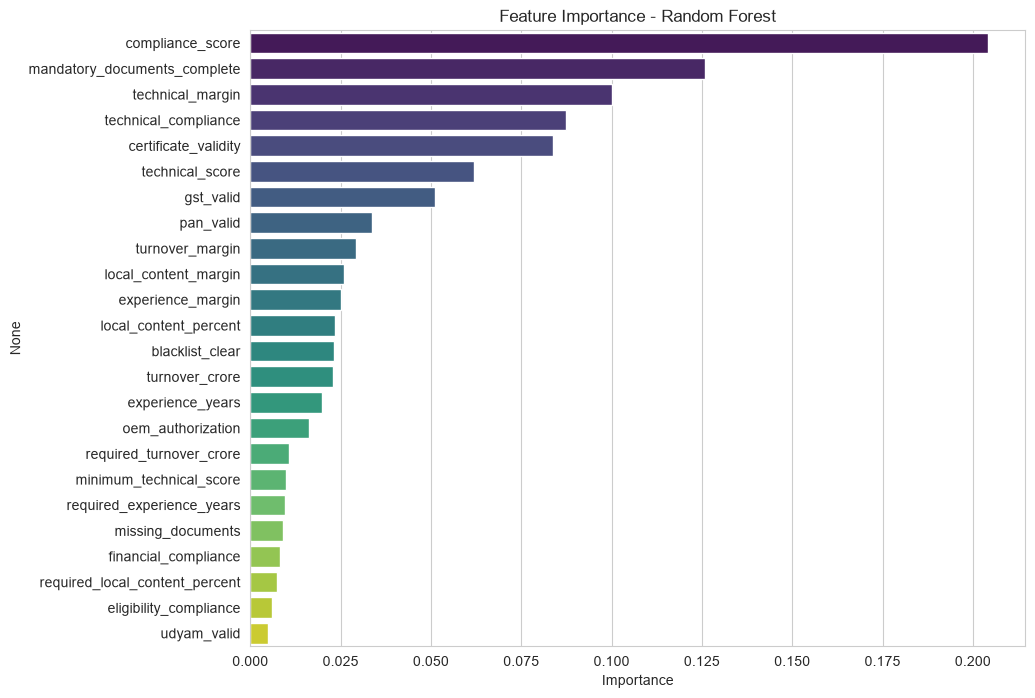

compliance_score                  0.204294
mandatory_documents_complete      0.125934
technical_margin                  0.100093
technical_compliance              0.087509
certificate_validity              0.083774
technical_score                   0.061829
gst_valid                         0.051032
pan_valid                         0.033545
turnover_margin                   0.029194
local_content_margin              0.026032
experience_margin                 0.025070
local_content_percent             0.023413
blacklist_clear                   0.023291
turnover_crore                    0.022875
experience_years                  0.019924
oem_authorization                 0.016212
required_turnover_crore           0.010709
minimum_technical_score           0.009938
required_experience_years         0.009705
missing_documents                 0.009133
financial_compliance              0.008122
required_local_content_percent    0.007465
eligibility_compliance            0.006056
udyam_valid

In [18]:
tree_model_name = 'Random Forest' if 'Random Forest' in results else best_model_name
importances = results[tree_model_name]['model'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title(f'Feature Importance - {tree_model_name}')
plt.xlabel('Importance')
plt.show()

feat_imp

## 11. Cross-Validation (Best Model Sanity Check)

In [19]:
cv_data = X_train_scaled if best_model_name == 'Logistic Regression' else X_train
cv_scores = cross_val_score(best['model'], cv_data, y_train, cv=5, scoring='f1')
print(f"5-Fold CV F1 scores: {cv_scores}")
print(f"Mean F1: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

5-Fold CV F1 scores: [0.94321767 0.95924765 0.9480315  0.9470405  0.95178849]
Mean F1: 0.9499  |  Std: 0.0054


## 12. Save Best Model

In [20]:
joblib.dump(best['model'], 'best_tender_classifier.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print(f"Saved best model: {best_model_name}")
print("Files: best_tender_classifier.pkl, scaler.pkl, label_encoder.pkl")

Saved best model: Gradient Boosting
Files: best_tender_classifier.pkl, scaler.pkl, label_encoder.pkl


## 13. Example: Predict on a New Bid

In [21]:
def predict_tender_result(record: dict):
    """
    record: dict with keys matching feature_names (raw fields, before derived margins)
    Returns predicted label and probability of PASS.
    """
    row = pd.DataFrame([record])
    row['turnover_margin'] = row['turnover_crore'] - row['required_turnover_crore']
    row['experience_margin'] = row['experience_years'] - row['required_experience_years']
    row['technical_margin'] = row['technical_score'] - row['minimum_technical_score']
    row['local_content_margin'] = row['local_content_percent'] - row['required_local_content_percent']
    row = row[feature_names]

    if best_model_name == 'Logistic Regression':
        row_input = scaler.transform(row)
    else:
        row_input = row

    pred = best['model'].predict(row_input)[0]
    prob = best['model'].predict_proba(row_input)[0][1]
    label = le.inverse_transform([pred])[0]
    return label, prob

# Example usage (fill in real values from your raw columns):
sample = df_fe.drop(columns=['tender_id', 'result']).iloc[0].to_dict()
# revert derived cols to raw for demo since function recomputes them
for c in ['turnover_margin','experience_margin','technical_margin','local_content_margin']:
    sample.pop(c, None)

label, prob = predict_tender_result(sample)
print(f"Predicted result: {label}  (P(PASS) = {prob:.3f})")

Predicted result: PASS  (P(PASS) = 0.918)
